# EDA in pandas and duckdb for Stockholm cultural events (Metrics and KPI) 

In [106]:
# Import (Pandas + DuckDB + Matplotlib)

import pandas as pd
import duckdb
import matplotlib.pyplot as plt

In [107]:
# Load data and quick checks/exploration of dataset

df = pd.read_csv("app/data/output/events_full_year.csv")

df.head()


,event_id,name,url,image_url,date,time,status,segment,genre,subgenre,venue_name,venue_city,venue_address,venue_lat,venue_lon,day_of_week,month_name,month_num,year,hour
0,Z698xZq2Z16vAkOybO,Labero's Magic World,https://www.ticketmaster.se/event/laberos-magi...,https://s1.ticketm.net/dam/a/f00/7a24bdb3-8f78...,2026-04-11,18:00:00,onsale,Miscellaneous,Food & Drink,Food & Drink,La Botanica,Stockholm,Tel: 08-751 09 65 - Stjärntorget 2,59.368980,18.005850,Saturday,April,4,2026,18
1,Z698xZq2Z16vQo0Eox,Svartklubben - Mat & Musik i Mörker,https://www.ticketmaster.se/event/svartklubben...,https://s1.ticketm.net/dam/a/841/1c1b2a57-616a...,2026-04-11,18:00:00,onsale,Arts & Theatre,Theatre,Miscellaneous,Svartklubben,Stockholm,Södermannagatan 27,59.312090,18.081330,Saturday,April,4,2026,18
2,Z698xZq2Z16vF3k9G0,MAMMA MIA! THE PARTY,https://www.ticketmaster.se/event/mamma-mia-th...,https://s1.ticketm.net/dam/e/d78/e055a3c6-df72...,2026-04-11,19:30:00,onsale,Arts & Theatre,Theatre,Miscellaneous,Tyrol,Stockholm,Lilla Allmänna Gränd 2,59.324127,18.096259,Saturday,April,4,2026,19
3,Z698xZq2Z1k-Skb4F,Bo Kaspers Orkester - Il magnifico,https://www.ticketmaster.se/event/bo-kaspers-o...,https://s1.ticketm.net/dam/e/9f5/189e04cc-d86d...,2026-04-11,19:30:00,onsale,Music,Rock,Pop,Göta Lejon,Stockholm,Götgatan 55,59.313780,18.073840,Saturday,April,4,2026,19
4,Z698xZq2Z1k_y_Mo_,& Julia,https://www.ticketmaster.se/event/-julia-bilje...,https://s1.ticketm.net/dam/a/9d5/39c257d4-fad5...,2026-04-11,19:30:00,onsale,Arts & Theatre,Theatre,Miscellaneous,Cirkus,Stockholm,Djurgårdsslätten 43-45,59.324570,18.099690,Saturday,April,4,2026,19


In [108]:
df.describe()

,venue_lat,venue_lon,month_num,year,hour
count,635.000000,635.000000,635.000000,635.000000,635.000000
mean,59.380313,18.141746,7.168504,2026.042520,17.919685
std,0.183879,0.225299,2.979152,0.201931,2.808534
min,59.290450,18.000410,1.000000,2026.000000,0.000000
25%,59.313780,18.063860,5.000000,2026.000000,18.000000
50%,59.324570,18.081330,6.000000,2026.000000,19.000000
75%,59.336230,18.099690,10.000000,2026.000000,19.000000
max,59.993330,18.890620,12.000000,2027.000000,22.000000


In [109]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 635 entries, 0 to 634
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   event_id       635 non-null    str    
 1   name           635 non-null    str    
 2   url            635 non-null    str    
 3   image_url      635 non-null    str    
 4   date           635 non-null    str    
 5   time           635 non-null    str    
 6   status         635 non-null    str    
 7   segment        635 non-null    str    
 8   genre          635 non-null    str    
 9   subgenre       635 non-null    str    
 10  venue_name     635 non-null    str    
 11  venue_city     635 non-null    str    
 12  venue_address  633 non-null    str    
 13  venue_lat      635 non-null    float64
 14  venue_lon      635 non-null    float64
 15  day_of_week    635 non-null    str    
 16  month_name     635 non-null    str    
 17  month_num      635 non-null    int64  
 18  year           635 no

## Connect duckdb (Duckdb sql for analysis ) 

In [110]:
con = duckdb.connect()
con.register("events", df)  #register table "events"in df for queries 

## Events per segment

In [111]:
events_per_segment= con.execute("""
    SELECT segment, COUNT(*) as total_events
    FROM events
    GROUP BY segment
    ORDER BY total_events DESC
    """).df()

events_per_segment

,segment,total_events
0,Arts & Theatre,426
1,Music,152
2,Miscellaneous,53
3,Sports,4


## Events per genre

In [112]:
events_per_game= con.execute("""
    SELECT genre, COUNT(*) as total_events
    FROM events
    GROUP BY genre
    ORDER BY total_events DESC
    """).df()

events_per_game

,genre,total_events
0,Theatre,233
1,Comedy,95
2,Dance,63
3,Rock,59
4,Other,37
5,Food & Drink,31
6,Family,19
7,Hip-Hop/Rap,19
8,Spectacular,12
9,Magic & Illusion,11


## Most repeated events(Top 10)

In [113]:
most_repeated_events= con.execute("""
    SELECT name, COUNT(*) AS occurrences
    FROM events
    GROUP BY name
    ORDER BY occurrences DESC
    LIMIT 10;
    """).df()

most_repeated_events


,name,occurrences
0,MAMMA MIA! THE PARTY,89
1,Torka aldrig tårar utan handskar,52
2,Svartklubben - Mat & Musik i Mörker,40
3,& Julia,36
4,Fredrik ”Benke” Rydman – Romeo & Julia,18
5,Labero's Magic World,15
6,MAFFIA COMEDY SUPERWEEKEND,13
7,Bo Kaspers Orkester - Il magnifico,13
8,Tomten är far till alla barnen,12
9,HippHipp Live!,8


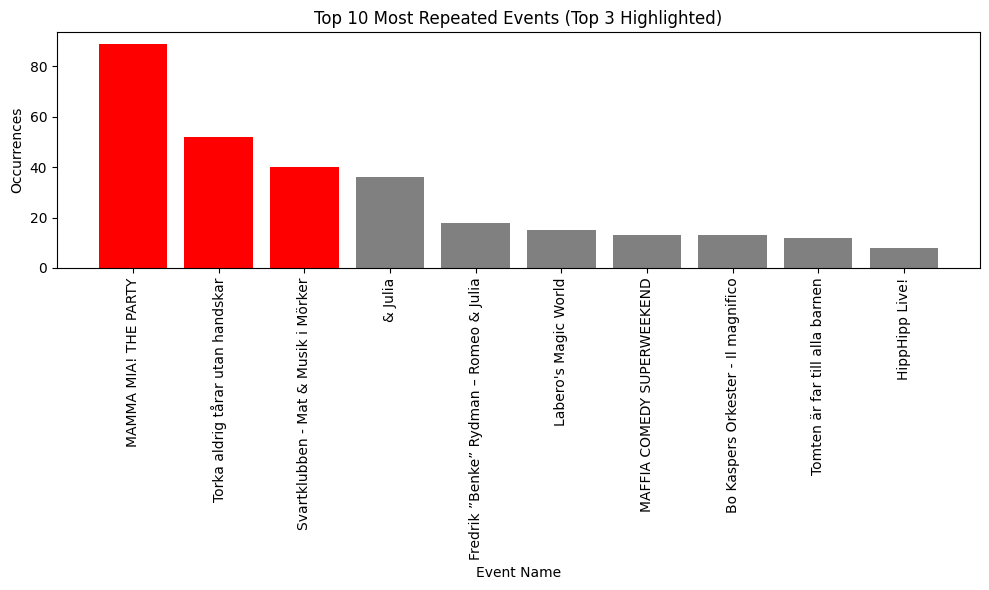

In [114]:
fig, ax = plt.subplots(figsize=(10,6))

# Sort data (important)
data = most_repeated_events.sort_values(by="occurrences", ascending=False)

# Top 3 events
top3 = data.head(3)["name"]

# Colors (highlight top 3)
colors = ["red" if name in top3.values else "grey"
          for name in data["name"]]

# Plot
ax.bar(data["name"], data["occurrences"], color=colors)

# Labels
ax.set_title("Top 10 Most Repeated Events (Top 3 Highlighted)")
ax.set_xlabel("Event Name")
ax.set_ylabel("Occurrences")
ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

## Top venues by event volume(Top 10)

In [115]:
top_venues_by_event_vol= con.execute("""
    SELECT venue_name, COUNT(*) AS total_events
    FROM events
    GROUP BY venue_name
    ORDER BY total_events DESC
    LIMIT 10;
    """).df()

top_venues_by_event_vol

,venue_name,total_events
0,Göta Lejon,97
1,Cirkus,91
2,Tyrol,91
3,Clarion Hotel Sign,52
4,Svartklubben,41
5,Dansens Hus - Stora Scen,31
6,Nya Cirkus,26
7,Strawberry Arena,25
8,Rival,21
9,Scen Studio Fyra,16


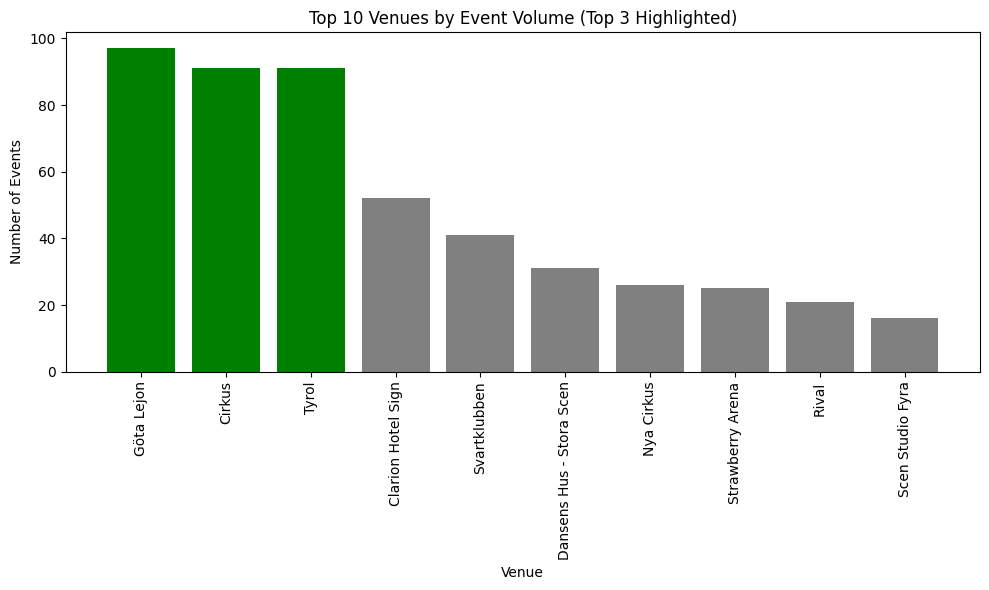

In [116]:
fig, ax = plt.subplots(figsize=(10,6))

# Sort data (important)
data = top_venues_by_event_vol.sort_values(by="total_events", ascending=False)

# Top 3 venues
top3 = data.head(3)["venue_name"]

# Colors (highlight top 3)
colors = ["green" if venue in top3.values else "grey"
          for venue in data["venue_name"]]

# Plot
ax.bar(data["venue_name"], data["total_events"], color=colors)

# Labels
ax.set_title("Top 10 Venues by Event Volume (Top 3 Highlighted)")
ax.set_xlabel("Venue")
ax.set_ylabel("Number of Events")
ax.tick_params(axis='x', rotation=90)


plt.tight_layout()
plt.show()

## Events by day of week

In [117]:
events_by_day_of_the_week= con.execute("""
    SELECT day_of_week, COUNT(*) AS total_events
    FROM events
    GROUP BY day_of_week
    ORDER BY total_events DESC;
    """).df()

events_by_day_of_the_week

,day_of_week,total_events
0,Saturday,247
1,Friday,144
2,Thursday,87
3,Sunday,55
4,Wednesday,45
5,Tuesday,33
6,Monday,24


## Events by month of the year 

In [ ]:
events_by_month_of_year= con.execute("""
    SELECT month_name, COUNT(*) AS total_events
    FROM events
    GROUP BY month_name
    ORDER BY total_events DESC;
    """).df()

events_by_month_of_year

,month_name,total_events
0,May,156
1,April,115
2,October,90
3,November,75
4,December,45
5,September,45
6,June,43
7,August,30
8,July,16
9,January,13


## Segment - Genre breakdown

In [119]:
segment_genre= con.execute("""
    SELECT segment, genre, COUNT(*) AS total
    FROM events
    GROUP BY segment, genre
    ORDER BY total DESC;
    """).df()

segment_genre

,segment,genre,total
0,Arts & Theatre,Theatre,233
1,Arts & Theatre,Comedy,95
2,Arts & Theatre,Dance,63
3,Music,Rock,59
4,Music,Other,37
5,Miscellaneous,Food & Drink,31
6,Miscellaneous,Family,19
7,Music,Hip-Hop/Rap,19
8,Arts & Theatre,Spectacular,12
9,Arts & Theatre,Magic & Illusion,11


## Peak hours oveerall 

In [120]:
overall_peak_hours= con.execute("""
    SELECT hour, COUNT(*) AS total_events
    FROM events
    GROUP BY hour
    ORDER BY hour;
    """).df()

overall_peak_hours

,hour,total_events
0,0,7
1,1,1
2,11,10
3,12,1
4,13,20
5,14,7
6,15,47
7,16,24
8,17,15
9,18,127


## Filter events(names) with their segments and genre that occur in Strawberry Arena

In [121]:
events_in_strwb_arena=con.execute("""
   SELECT DISTINCT name, segment, genre
    FROM events
    WHERE venue_name = 'Strawberry Arena'
    """).df()

events_in_strwb_arena

,name,segment,genre
0,System Of A Down I VIP Packages,Music,Other
1,Bad Bunny - DeBÍ TiRAR MáS FOToS World Tour | ...,Music,Rock
2,Bad Bunny - DeBÍ TiRAR MáS FOToS World Tour | ...,Music,Latin
3,System Of A Down,Music,Rock
4,Manchester United – Atlético de Madrid | Suite...,Sports,Soccer
5,The Weeknd: After Hours Til Dawn Tour | VIP Pa...,Music,Other
6,The Weeknd: After Hours Til Dawn Tour | Hotel ...,Music,Hip-Hop/Rap
7,The Weeknd I Strawberry Arena Premium Experien...,Music,Hip-Hop/Rap
8,System Of A Down | Strawberry Arena Premium Ex...,Music,Metal
9,The Weeknd: After Hours Til Dawn Tour,Music,Other


## Top 5 Genre 

In [122]:
top_5_genres = con.execute("""
    SELECT genre, COUNT(*) AS total_events
    FROM events
    GROUP BY genre
    ORDER BY total_events DESC
    LIMIT 5;
""").df()


top_5_genres

,genre,total_events
0,Theatre,233
1,Comedy,95
2,Dance,63
3,Rock,59
4,Other,37


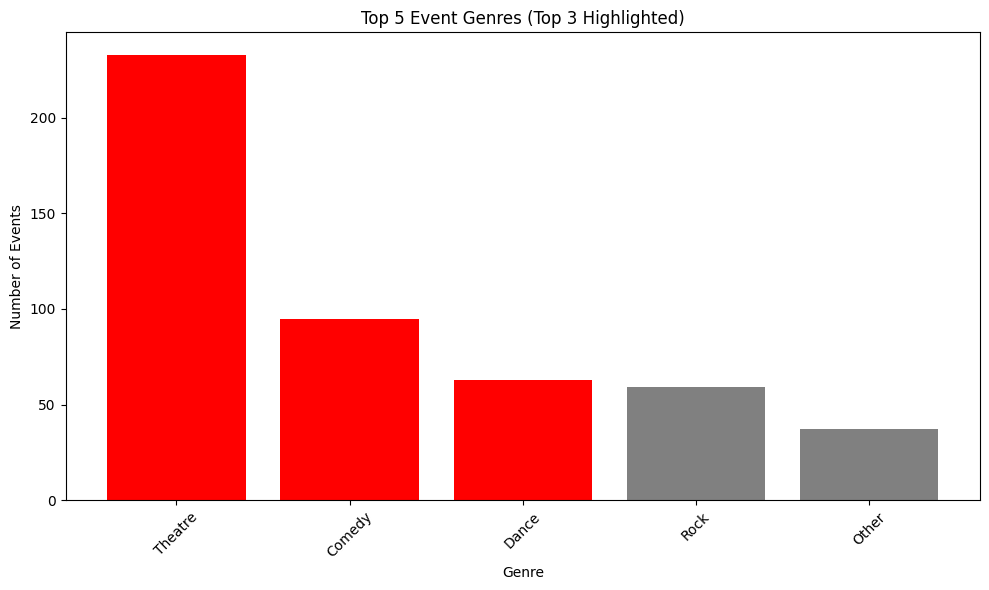

In [123]:
fig, ax = plt.subplots(figsize=(10,6))

# Sort data
data = top_5_genres.sort_values(by="total_events", ascending=False)

# Identify top 3
top3 = data.head(3)["genre"]

# Create colors
colors = ["red" if data in top3.values else "grey"
          for data in data["genre"]]

# Plot
ax.bar(data["genre"], data["total_events"], color=colors)

# Labels
ax.set_title("Top 5 Event Genres (Top 3 Highlighted)")
ax.set_xlabel("Genre")
ax.set_ylabel("Number of Events")
ax.tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()